# Clustering based on clock genes (or other pre-determined gene list)

In [ ]:
dir_notebook = '../notebook'
name_dir = 'circa-SD'

df = pd.read_parquet(f'{dir_notebook}/csv/circa-SD/circa-SD_norm_combined.parquet')

In [ ]:
df_sub = df[df['cell_type_final'] == "Astro TE"]
df_sub.head()

,A1cf,A2m,Aatf,Abca1,Abca13,Abca3,Abca4,Abca7,Abca8a,Abca8b,...,cell_id,sample,ZT,run,cell_type_final,region_automap_name,cell_class,circascore,x_centroid,y_centroid
circa4-IGM-ZT01_aaaadmjm-1,0.0,0.0,0.000000,0.0,0.0,0.525810,0.0,0.0,0.0,0.0,...,circa4-IGM-ZT01_aaaadmjm-1,circa4-IGM-ZT01,ZT01,circa4,Astro TE,CTX,Glial,5,3182.524170,1087.921265
circa4-IGM-ZT01_aaacokfd-1,0.0,0.0,0.734025,0.0,0.0,0.734025,0.0,0.0,0.0,0.0,...,circa4-IGM-ZT01_aaacokfd-1,circa4-IGM-ZT01,ZT01,circa4,Astro TE,AHN,Glial,1,4122.383301,1055.101685
circa4-IGM-ZT01_aaadmfie-1,0.0,0.0,0.532059,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,circa4-IGM-ZT01_aaadmfie-1,circa4-IGM-ZT01,ZT01,circa4,Astro TE,WM,Glial,1,3952.806885,932.128662
circa4-IGM-ZT01_aaadpehl-1,0.0,0.0,0.000000,0.0,0.0,0.393429,0.0,0.0,0.0,0.0,...,circa4-IGM-ZT01_aaadpehl-1,circa4-IGM-ZT01,ZT01,circa4,Astro TE,SCH,Glial,2,5199.329590,985.317993
circa4-IGM-ZT01_aaafijpd-1,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,circa4-IGM-ZT01_aaafijpd-1,circa4-IGM-ZT01,ZT01,circa4,Astro TE,LHA,Glial,2,3587.612305,1691.126709


In [ ]:
from module.misc import genes_list

clock_genes = genes_list("clock")

# df_sub = df_sub.filter(clock_genes, axis = 1)
# df_sub.index

In [ ]:
from sklearn.preprocessing import StandardScaler

pca = PCA(n_components=2)

x = df_sub.loc[:, clock_genes].values
x = StandardScaler().fit_transform(x)

principalComponents = pca.fit_transform(x)

finalDf = pd.DataFrame(data = principalComponents , columns = ['principal component 1', 'principal component 2'])

X_pca = principalComponents
kmeans = KMeans(n_clusters=2,
                random_state=0).fit(X_pca)

finalDf['cluster'] = kmeans.labels_
finalDf['cell_id'] = df_sub.index

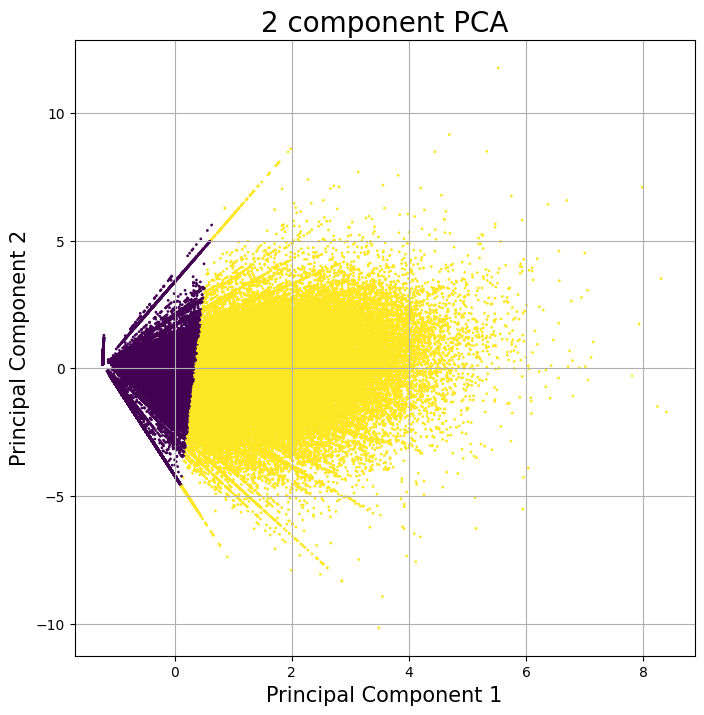

In [ ]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)

ax.scatter(finalDf['principal component 1'], finalDf['principal component 2'], c = finalDf['cluster'], s = 1)
ax.grid()

In [ ]:
df_sub['cluster'] = df_sub.index.map(dict(zip(finalDf['cell_id'],finalDf['cluster'])))
df_sub['x_centroid'] = df_sub.index.map(dict(zip(df['cell_id'],df['x_centroid'])))
df_sub['y_centroid'] = df_sub.index.map(dict(zip(df['cell_id'],df['y_centroid'])))
df_sub['sample'] = df_sub.index.map(dict(zip(df['cell_id'],df['sample'])))
df_sub['sample'].unique()

array(['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09',
       'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21',
       'SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17',
       'SD1-ZT21'], dtype=object)

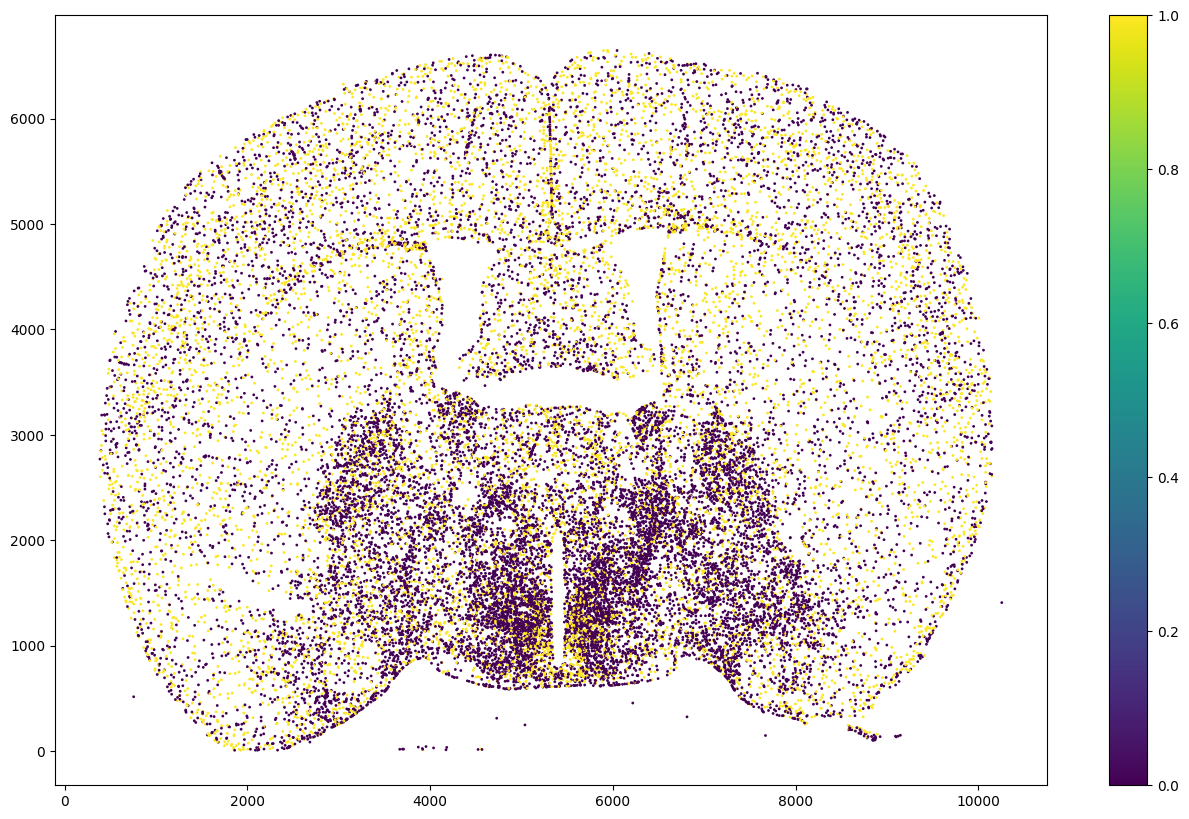

In [ ]:
plt.figure(figsize = (16,10))
plt.scatter(df_sub[df_sub['sample']=='circa4-IGM-ZT01']['x_centroid'], df_sub[df_sub['sample']=='circa4-IGM-ZT01']['y_centroid'],c=df_sub[df_sub['sample']=='circa4-IGM-ZT01']['cluster'], s = 1)
plt.colorbar()

In [ ]:
import umap
reducer = umap.UMAP()
embedding = reducer.fit_transform(x)
embedding.shape

(355773, 2)

In [ ]:
finalDf_umap = pd.DataFrame(data = embedding , columns = ['principal component 1', 'principal component 2'])

X_pca = embedding
kmeans = KMeans(#n_clusters=2,
                random_state=0).fit(X_pca)

finalDf_umap['cluster'] = kmeans.labels_
finalDf_umap['cell_id'] = df_sub.index

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


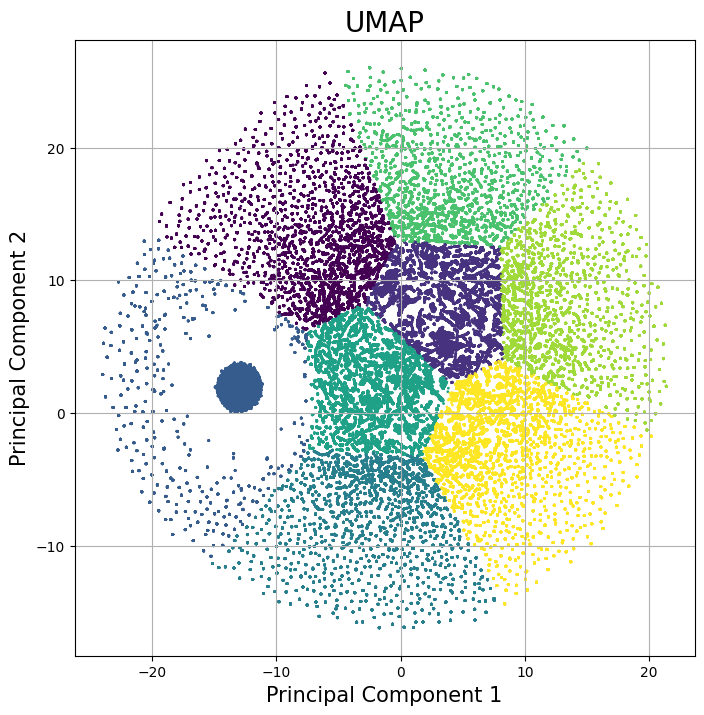

In [ ]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('UMAP', fontsize = 20)

ax.scatter(finalDf_umap['principal component 1'], finalDf_umap['principal component 2'], c = finalDf_umap['cluster'], s = 1)
ax.grid()

In [ ]:
df_sub['cluster_umap'] = df_sub.index.map(dict(zip(finalDf_umap['cell_id'],finalDf_umap['cluster'])))
df_sub['x_centroid'] = df_sub.index.map(dict(zip(df['cell_id'],df['x_centroid'])))
df_sub['y_centroid'] = df_sub.index.map(dict(zip(df['cell_id'],df['y_centroid'])))
df_sub['sample'] = df_sub.index.map(dict(zip(df['cell_id'],df['sample'])))
df_sub['sample'].unique()

array(['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09',
       'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21',
       'SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17',
       'SD1-ZT21'], dtype=object)

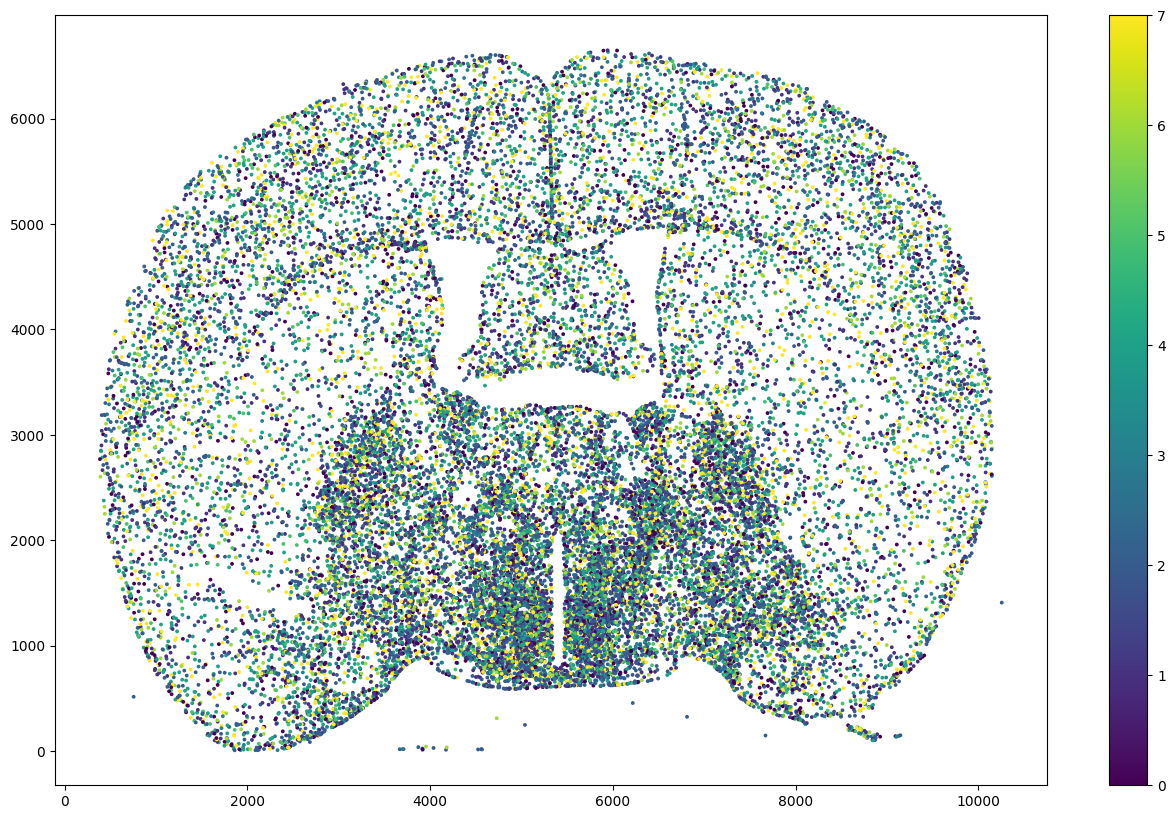

In [ ]:
plt.figure(figsize = (16,10))
plt.scatter(df_sub[df_sub['sample']=='circa4-IGM-ZT01']['x_centroid'], df_sub[df_sub['sample']=='circa4-IGM-ZT01']['y_centroid'],c=df_sub[df_sub['sample']=='circa4-IGM-ZT01']['cluster_umap'], s = 3)
plt.colorbar()

### Filter from adata

In [ ]:
clock_genes

['Arntl',
 'Clock',
 'Cry1',
 'Cry2',
 'Nr1d1',
 'Per1',
 'Per2',
 'Per3',
 'Rora',
 'Rorb',
 'Rorc',
 'Npas2']

In [ ]:
adata_subcluster = adata[:, adata.var_names.isin(clock_genes)].copy()

In [ ]:
adata_subcluster.obs['sample'].unique()

['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', ..., 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17', 'SD1-ZT21']
Length: 12
Categories (12, object): ['SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', ..., 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21']

In [ ]:
adata_subcluster = adata_subcluster[adata_subcluster.obs['cell_type_final']=="Oligodendrocyte"]
adata_subcluster = adata_subcluster[adata_subcluster.obs['sample']=='circa4-IGM-ZT01']
adata_subcluster.shape

(22620, 12)

In [ ]:
import scanpy as sc

sc.pp.pca(adata_subcluster)
sc.pp.neighbors(adata_subcluster)
sc.tl.umap(adata_subcluster)

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:229: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm['X_pca'] = X_pca


In [ ]:
# extract pca coordinates
X_pca = adata_subcluster.obsm['X_pca'] 

### Kmeans clustering
### You can choose the number of clusters by uncommenting n_clusters option
# kmeans = KMeans(#n_clusters=4,
#                 random_state=0).fit(X_pca) 
# adata_subcluster.obs['kmeans'] = kmeans.labels_.astype(str)

sc.tl.leiden(adata_subcluster, resolution = 0.1)

In [ ]:
clustering_method = 'leiden'

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):


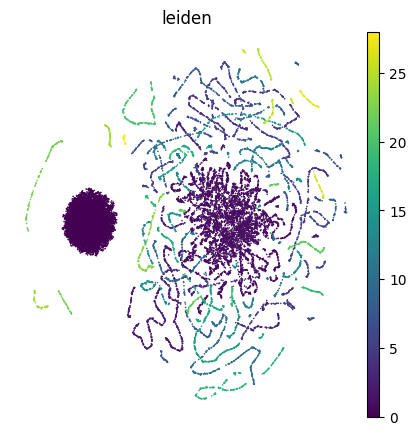

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):


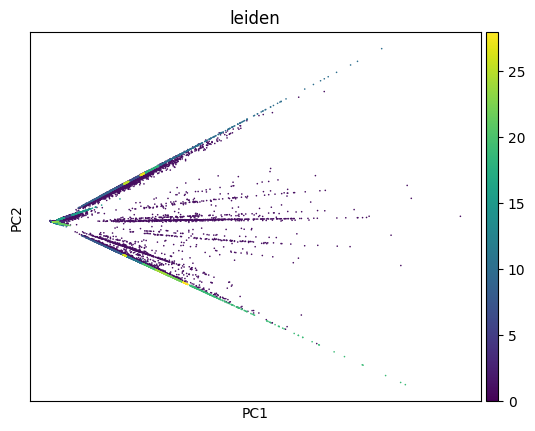

In [ ]:
from matplotlib.pyplot import rc_context
with rc_context({"figure.figsize": (5, 5)}):
    sc.pl.umap(
        adata_subcluster,
        color=clustering_method,
        add_outline=False,
        legend_loc="on data",
        legend_fontsize=12,
        legend_fontoutline=2,
        frameon=False,
        palette="tab20",
    )
sc.pl.pca(adata_subcluster,
         color=clustering_method,
         palette="tab20",
         )

In [ ]:
### Number of cells per clusters
max_clust = len(adata_subcluster.obs[clustering_method].unique())
for i in range(0, max_clust):
    count = adata_subcluster.obs[clustering_method].value_counts().iloc[i]
    print(f"Cluster {i} : {count} cells")

# adata_subcluster.obs['leiden'].sample(10)

Cluster 0 : 9125 cells
Cluster 1 : 6159 cells
Cluster 2 : 606 cells
Cluster 3 : 606 cells
Cluster 4 : 506 cells
Cluster 5 : 499 cells
Cluster 6 : 461 cells
Cluster 7 : 401 cells
Cluster 8 : 400 cells
Cluster 9 : 342 cells
Cluster 10 : 330 cells
Cluster 11 : 322 cells
Cluster 12 : 318 cells
Cluster 13 : 267 cells
Cluster 14 : 239 cells
Cluster 15 : 224 cells
Cluster 16 : 216 cells
Cluster 17 : 207 cells
Cluster 18 : 198 cells
Cluster 19 : 191 cells
Cluster 20 : 183 cells
Cluster 21 : 173 cells
Cluster 22 : 154 cells
Cluster 23 : 142 cells
Cluster 24 : 106 cells
Cluster 25 : 98 cells
Cluster 26 : 62 cells
Cluster 27 : 53 cells
Cluster 28 : 32 cells


In [ ]:
from module.misc import sample_name_import

name_dir = "circa-SD"

samples, samples_ids = sample_name_import(name_dir)

print(len(samples))
print(samples)

12
['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21', 'SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17', 'SD1-ZT21']


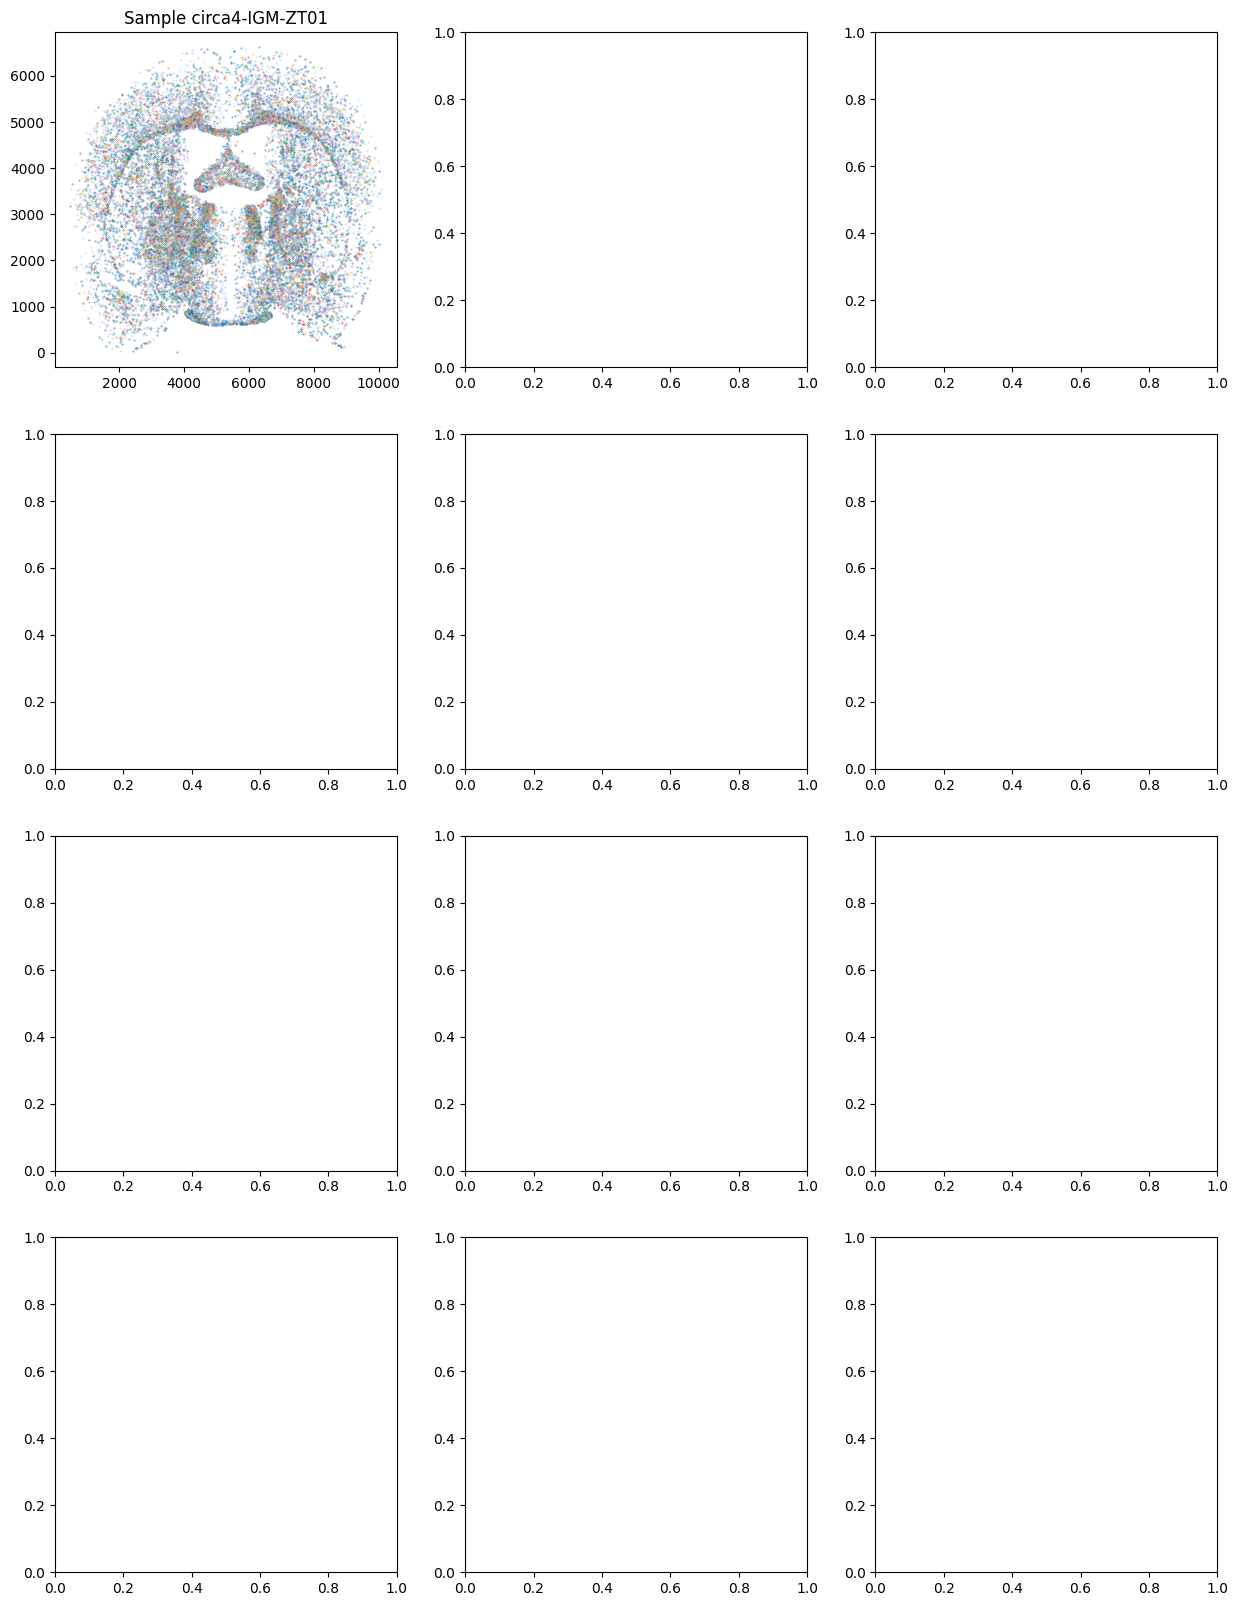

In [ ]:
import seaborn as sns

### Generate a color palette for the clusters - to make color stay consistent across samples
adata_subcluster.obs[clustering_method] = adata_subcluster.obs[clustering_method].astype(int)

# Create a palette with a unique color for each cluster
num_clusters = len(adata_subcluster.obs[clustering_method].unique())
palette = sns.color_palette("tab20", n_colors=num_clusters)

# Map each 'leiden' value to a color
adata_subcluster.obs['kmeans_colors'] = adata_subcluster.obs[clustering_method].apply(lambda x: palette[x])

# Mapping of clusters
fig, axs = plt.subplots(4,3,figsize=(15, 20))
axs = axs.flatten()
clusters_plot = {
    # 0: 'orchid', 1: 'forestgreen', 2: 'black', 3:'red', 4:'cyan', 5:'blue', 6:'darkorange',7:'coral',
    # 8:'forestgreen', 9: 'coral',10:'red', 11:'cyan',
    6:'blue',0:'darkorange', 14:'black'
}

for idx, sample in enumerate(samples_ids):
    adata_sel = adata_subcluster[(adata_subcluster.obs['sample'] == sample)]
    for cluster_id in adata_sel.obs[clustering_method].unique():
        cluster_data = adata_sel.obs[adata_sel.obs[clustering_method] == cluster_id]
        colors = clusters_plot[cluster_id] if cluster_id in clusters_plot else "none"
        colors= cluster_data['kmeans_colors'].unique()[0]
        axs[idx].scatter(cluster_data['x_centroid'], cluster_data['y_centroid'], color=colors, s=0.1, label=cluster_id)
        axs[idx].set_title(f"Sample {sample}")

<Axes: xlabel='leiden', ylabel='circascore'>

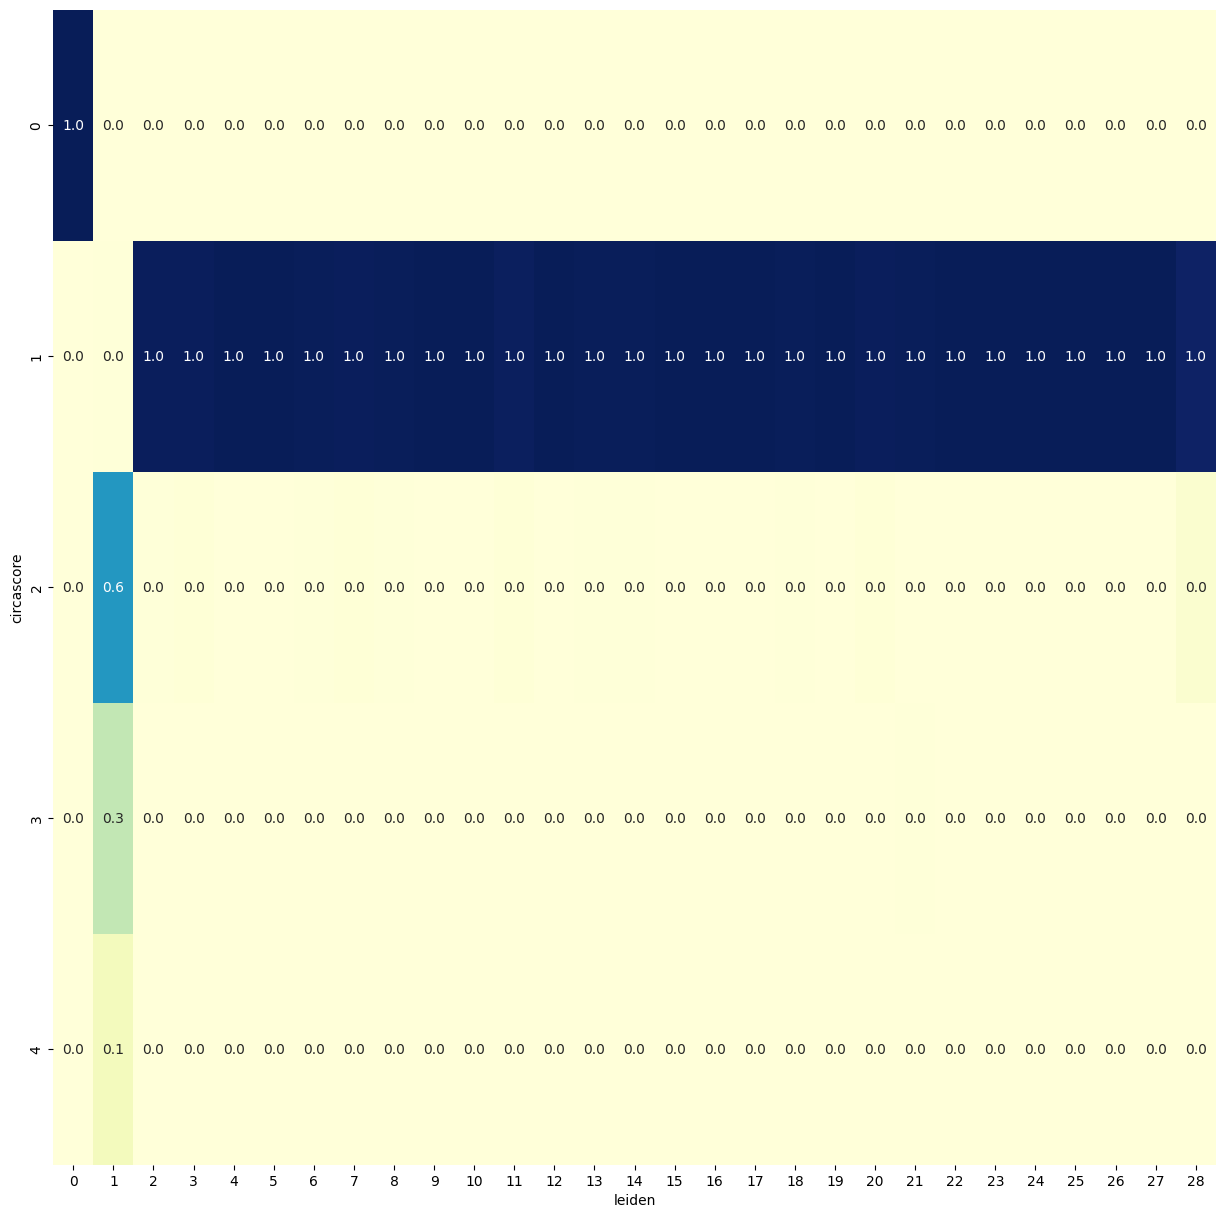

In [ ]:
### Correlation map of subclusters
cont_tab = pd.crosstab(adata_subcluster.obs[clustering_method], adata_subcluster.obs['circascore'], normalize="index")
cont_tab = cont_tab.loc[:, cont_tab.sum(axis=0) > 0.05]
plt.figure(figsize=(15, 15))
sns.heatmap(cont_tab.T, annot=True, cmap="YlGnBu", fmt=".1f", cbar=False) 

In [ ]:
df = pd.DataFrame(data=adata_subcluster.X.toarray(), index=adata_subcluster.obs_names, columns=adata_subcluster.var_names)

from module.xenium_preprocessing import add_annotations
df = add_annotations(adata_subcluster,df)
# name_dir = 'circa-SD'